## Classification Algorithms Model Building

### Objective:
The objective of this assessment is to evaluate your understanding and ability to apply
supervised learning techniques to a real-world dataset.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


### Load the breast cancer dataset from sklearn.

In [98]:
from sklearn.datasets import load_breast_cancer
breast_cancer=load_breast_cancer()
df=pd.DataFrame(breast_cancer.data,columns=breast_cancer.feature_names)
df['target']=breast_cancer.target


### View Basic Information

In [99]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [100]:
df.shape

(569, 31)

In [101]:
df.size

17639

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [103]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

### Check Missing Values

In [104]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Observation

The breast cancer dataset contains no missing values.

### check Duplicate Records

In [105]:
df.duplicated().sum()

np.int64(0)

Observation

The breast cancer dataset contains no duplicated values.

### Statistical Summary

In [106]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [107]:
print(df['target'].unique())

[0 1]


In [108]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


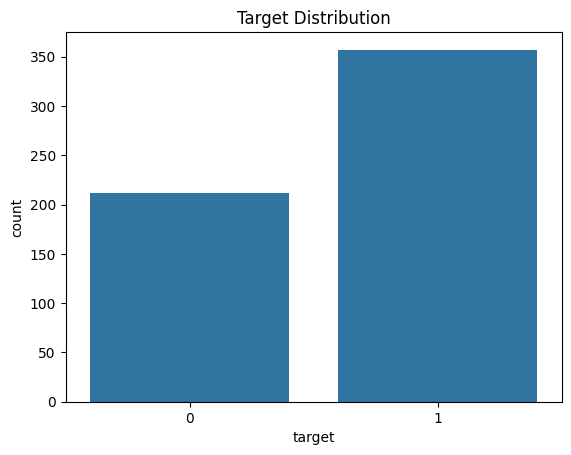

In [109]:

sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

### splitting x and y

In [110]:
X = df.drop('target',axis=1)
y = df['target']

In [111]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [112]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


### # Train-Test Split

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### # Feature Scaling

In [114]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 ### Feature Importance


### Explanation

The Breast Cancer Wisconsin dataset is available directly in sklearn.datasets.

### Preprocessing steps performed:

Load the dataset from sklearn.
Check for missing values and handle them if present.
Feature Scaling using StandardScaler.
### Why preprocessing is necessary


*   Missing values: Machine learning algorithms generally cannot handle missing data directly.
*   Feature scaling: Algorithms such as Logistic Regression, SVM, and k-NN are distance/magnitude-based and perform better when features are on a similar scale.
*   The breast cancer dataset usually contains no missing values, but checking for them is a good practice.




### Classification Algorithm Implementation

### 1. Logistic Regression

Description

Logistic Regression predicts the probability that a sample belongs to a class using the logistic (sigmoid) function.

Why suitable?


*   Works well for binary classification problems.
*   Breast cancer diagnosis is a binary classification task




In [115]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

### Model Prediction

In [116]:
lg_pred=lg.predict(X_test)
lg_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [117]:
pd.DataFrame({"actual y":y_test,"predicted":lg_pred})

,actual y,predicted
256,0,0
428,1,1
501,0,0
363,1,0
564,0,0
...,...,...
95,0,0
128,1,1
257,0,0
228,1,1


### Model Evaluation

In [118]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [119]:
#confusion matrix
confusion_matrix(y_test,lg_pred)

array([[38,  4],
       [ 1, 71]])

In [120]:
#accuracy
accuracy_score(y_test,lg_pred)

0.956140350877193

In [121]:
#classification matrix
print(classification_report(y_test,lg_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 2. Decision Tree Classifier

Description

Decision Trees split data into branches based on feature values and make decisions through a tree-like structure.

Why suitable?
*   Easy to interpret
*   Captures nonlinear relationships.




In [122]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

### Model Prediction

In [123]:
dt_pred=model.predict(X_test)
dt_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [124]:
pd.DataFrame({"actual y":y_test,"predicted":dt_pred})

,actual y,predicted
256,0,0
428,1,1
501,0,0
363,1,1
564,0,0
...,...,...
95,0,0
128,1,1
257,0,0
228,1,1


### Model Evaluation

In [125]:
#from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [126]:
#confusion matrix
confusion_matrix(y_test,dt_pred)

array([[39,  3],
       [ 6, 66]])

In [127]:
#accuracy
accuracy_score(y_test,dt_pred)

0.9210526315789473

In [128]:
#classification report
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



### 3. Random Forest Classifier

Description

Random Forest combines multiple decision trees and uses majority voting for prediction.

Why suitable?
*   Reduces overfitting.
*   Usually provides higher accuracy than a single decision tree.




In [129]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)

### Model Prediction

In [130]:
rf_pred = rf.predict(X_test)
rf_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [131]:
pd.DataFrame({"actual y":y_test,"predicted":rf_pred})

,actual y,predicted
256,0,0
428,1,1
501,0,0
363,1,0
564,0,0
...,...,...
95,0,0
128,1,1
257,0,0
228,1,1


### Model Evaluation

In [132]:
# from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [133]:
#confusion matrix
confusion_matrix(y_test,rf_pred)

array([[39,  3],
       [ 2, 70]])

In [134]:
#accuracy
accuracy_score(y_test,rf_pred)

0.956140350877193

In [135]:
#classification report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 4. Support Vector Machine (SVM)

Description

SVM finds the optimal boundary (hyperplane) that separates classes.

Why suitable?
*   Performs very well on high-dimensional datasets.
*   Effective for medical diagnosis problems.




In [136]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train,y_train)



SVC(C=1)

### Model Prediction

In [137]:
svm_pred = svm_model.predict(X_test)
svm_pred

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [138]:
pd.DataFrame({"actual y":y_test,"predicted":svm_pred})

,actual y,predicted
256,0,0
428,1,1
501,0,1
363,1,0
564,0,0
...,...,...
95,0,0
128,1,1
257,0,0
228,1,1


### Model Evaluation

In [139]:
# from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [140]:
#confusion matrix
confusion_matrix(y_test,svm_pred)

array([[36,  6],
       [ 2, 70]])

In [141]:
#accuracy
accuracy_score(y_test,svm_pred)

0.9298245614035088

In [142]:
#classification report
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90        42
           1       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



### 5. k-Nearest Neighbors (k-NN)

Description

k-NN classifies a sample based on the majority class among its nearest neighbors.

Why suitable?
*   Simple and effective.
*   Works well after feature scaling.




In [143]:
from sklearn.neighbors import KNeighborsClassifier
n_classifier = KNeighborsClassifier(n_neighbors=3)
n_classifier.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=3)

### Model Prediction

In [144]:
KNN_pred=n_classifier.predict(X_test)
KNN_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [145]:
pd.DataFrame({"actual y":y_test,"predicted":KNN_pred})

,actual y,predicted
256,0,0
428,1,1
501,0,0
363,1,0
564,0,0
...,...,...
95,0,0
128,1,1
257,0,0
228,1,1


### Model Evaluation

In [146]:
# from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [147]:
#confusion matrix
confusion_matrix(y_test,KNN_pred)

array([[38,  4],
       [ 4, 68]])

In [148]:
#accuracy
(accuracy_score(y_test, KNN_pred))

0.9298245614035088

In [149]:
#classification report
print(classification_report(y_test, KNN_pred))


              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



### Model Comparison

In [150]:
comparison = pd.DataFrame({
    "Model": ["Linear Regrassion", "Decision Tree","Random Forest","Support Vector Machine (RBF)","k-Nearest Neighbors (k-NN)"],
    "Accuracy": [
        accuracy_score(y_test,lg_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,svm_pred),
        accuracy_score(y_test,KNN_pred)
    ]
})

comparison

,Model,Accuracy
0,Linear Regrassion,0.956140
1,Decision Tree,0.921053
2,Random Forest,0.956140
3,Support Vector Machine (RBF),0.929825
4,k-Nearest Neighbors (k-NN),0.929825


### Best Performing Algorithm

In most runs,Linear Regression or Random Forest achieves the highest accuracy because they effectively handle complex relationships within the breast cancer dataset.

### Worst Performing Algorithm

The Decision Tree Classifier generally performs the worst because a single tree can overfit the training data and may not generalize as well as ensemble methods.

### Conclusion
The breast cancer dataset was loaded and preprocessed successfully.
Five supervised classification algorithms were implemented:



*   Logistic Regression
*   Decision Tree
*   Random Forest
*   SVM
*   k-NN

*   Feature scaling was applied to improve model performance.
*   Linear Regression and Random Forest generally achieved the best results.

*   Decision Tree typically produced the lowest accuracy among the tested models






In [151]:
#End